
# Pelvis KNN Regression — Five Experiments

Predict left and right 3D ground reaction forces from pelvis IMU data.

| Experiment | Model inputs |
|---|---|
| 1 | Raw IMU |
| 2 | Raw IMU with a different K search |
| 3 | Raw IMU + mean, standard deviation, minimum, and maximum |
| 4 | Raw IMU + acceleration and gyroscope magnitudes |
| 5 | Raw IMU + statistics + magnitudes |

- Participant split: 40 training, 9 validation, 9 testing.
- Input scaling: StandardScaler fitted on training inputs only.
- KNN: Euclidean distance and uniform neighbour weighting.
- K selection: Lowest validation RMSE.
- Sensitivity analysis: Validation RMSE table and plot across K.
- Test metrics: RMSE, Pearson correlation, and R².
- Outputs: Left and right Fx, Fy, and Fz.

## **1. Notebook set-up**

In [1]:
from pathlib import Path
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.neighbors import (
    KNeighborsRegressor
)

from sklearn.preprocessing import (
    StandardScaler
)

In [2]:
DATA_ROOT = Path("/kaggle/input")

files = list(
    DATA_ROOT.rglob("combined_pelvis_bilateral_grf.csv")
)

print("Matching files:", len(files))

for file in files:
    print(file)

assert len(files) == 1, "Expected one matching pelvis file."

Matching files: 1
/kaggle/input/datasets/toffickmohammed/gait-mphil-research-data/combined_pelvis_bilateral_grf.csv


In [3]:
pelvis = pd.read_csv(
    files[0],
    dtype={"Participant": str}
)

print("Dataset shape:", pelvis.shape)
display(pelvis.head())

Dataset shape: (1015, 1204)


,Dataset,Participant,Trial,Side,Pelvis_Acc_X_t0,Pelvis_Acc_X_t1,Pelvis_Acc_X_t2,Pelvis_Acc_X_t3,Pelvis_Acc_X_t4,Pelvis_Acc_X_t5,...,GRF_Right_Fz_t90,GRF_Right_Fz_t91,GRF_Right_Fz_t92,GRF_Right_Fz_t93,GRF_Right_Fz_t94,GRF_Right_Fz_t95,GRF_Right_Fz_t96,GRF_Right_Fz_t97,GRF_Right_Fz_t98,GRF_Right_Fz_t99
0,Lavikainen,01,l_comf_01,Bilateral,13.867336,12.599382,11.367044,12.683041,15.075952,15.030770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Lavikainen,01,l_comf_02,Bilateral,13.539703,12.185856,11.601151,13.073038,13.831650,12.348832,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Lavikainen,01,l_comf_03,Bilateral,13.356306,13.091857,11.960903,11.781584,13.496060,14.636293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Lavikainen,01,l_comf_04,Bilateral,13.174028,12.261867,11.914104,13.159199,13.695015,12.421048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Lavikainen,01,l_comf_05,Bilateral,13.039537,12.526015,11.685674,12.857979,14.537988,13.939563,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
TIME_POINTS = 100

IMU_CHANNELS = [
    "Acc_X", "Acc_Y", "Acc_Z",
    "Gyr_X", "Gyr_Y", "Gyr_Z"
]

GRF_CHANNELS = [
    "Left_Fx", "Left_Fy", "Left_Fz",
    "Right_Fx", "Right_Fy", "Right_Fz"
]

METADATA = [
    "Dataset", "Participant", "Trial", "Side"
]

In [5]:
x_columns = [
    f"Pelvis_{channel}_t{t}"
    for channel in IMU_CHANNELS
    for t in range(TIME_POINTS)
]

y_columns = [
    f"GRF_{channel}_t{t}"
    for channel in GRF_CHANNELS
    for t in range(TIME_POINTS)
]

required = METADATA + x_columns + y_columns
missing = set(required) - set(pelvis.columns)

print("Missing columns:", sorted(missing))
assert not missing, "Required columns are missing."

print("Input features:", len(x_columns))
print("Target features:", len(y_columns))

Missing columns: []
Input features: 600
Target features: 600


In [6]:
assert not pelvis[METADATA].isna().any().any(), "Missing metadata."

signals = pelvis[x_columns + y_columns].to_numpy(dtype=float)

assert np.isfinite(signals).all(), "Missing or infinite signal values."

print("Missing-value checks passed.")

Missing-value checks passed.


In [7]:
pelvis["Group_ID"] = (
    pelvis["Dataset"].astype(str).str.strip()
    + "::"
    + pelvis["Participant"].str.strip()
)

participants = pelvis["Group_ID"].nunique()

print("Participants:", participants)
assert participants == 58, "Expected 58 participants."

display(
    pelvis.groupby("Dataset")["Group_ID"].nunique()
)

Participants: 58


Dataset
Grouvel       10
Lavikainen    48
Name: Group_ID, dtype: int64

In [8]:
pelvis["Side"] = (
    pelvis["Side"].str.strip().str.title()
)

display(pelvis["Side"].value_counts())

assert pelvis["Side"].isin(
    ["Left", "Right", "Bilateral"]
).all(), "Unexpected Side labels."

Side
Bilateral    935
Left          45
Right         35
Name: count, dtype: int64

## 2. Create participant splits

In [9]:
participant_table = (
    pelvis[["Group_ID", "Dataset", "Participant"]]
    .drop_duplicates("Group_ID")
    .reset_index(drop=True)
)

print("Participants:", len(participant_table))
print(participant_table["Dataset"].value_counts())

Participants: 58
Dataset
Lavikainen    48
Grouvel       10
Name: count, dtype: int64


In [10]:
SEED = 42

train_table, remaining_table = train_test_split(
    participant_table,
    train_size=40,
    test_size=18,
    stratify=participant_table["Dataset"],
    random_state=SEED
)

val_table, test_table = train_test_split(
    remaining_table,
    train_size=9,
    test_size=9,
    stratify=remaining_table["Dataset"],
    random_state=SEED
)

train_ids = train_table["Group_ID"].to_numpy()
val_ids = val_table["Group_ID"].to_numpy()
test_ids = test_table["Group_ID"].to_numpy()

In [11]:
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)

print("Training:", len(train_ids))
print("Validation:", len(val_ids))
print("Testing:", len(test_ids))
print("Participant overlap: None")

Training: 40
Validation: 9
Testing: 9
Participant overlap: None


In [12]:
split_table = pd.concat([
    train_table.assign(Split="Train"),
    val_table.assign(Split="Validation"),
    test_table.assign(Split="Test")
], ignore_index=True)

display(
    split_table.groupby(["Split", "Dataset"])
    ["Group_ID"].nunique()
)

Split       Dataset   
Test        Grouvel        2
            Lavikainen     7
Train       Grouvel        7
            Lavikainen    33
Validation  Grouvel        1
            Lavikainen     8
Name: Group_ID, dtype: int64

### **Experiment one**

In [13]:
## experiment settings
EXPERIMENT = "experiment_1_raw_pelvis"

SENSORS = ["Pelvis"]

K_VALUES = list(range(1, 101, 5)) + [100]

WEIGHTS = "uniform"
METRIC = "euclidean"

OUTPUT_PATH = (
    Path("/kaggle/working") / EXPERIMENT
)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Experiment:", EXPERIMENT)
print("K values:", K_VALUES)
print("Save location:", OUTPUT_PATH)

Experiment: experiment_1_raw_pelvis
K values: [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96, 100]
Save location: /kaggle/working/experiment_1_raw_pelvis


In [14]:
## prepare the data
def prepare_raw_data(df):
    X = df[x_columns].to_numpy(dtype=np.float32)
    y = df[y_columns].to_numpy(dtype=np.float32)

    split_ids = {
        "train": train_ids,
        "val": val_ids,
        "test": test_ids
    }

    data = {}

    for split, ids in split_ids.items():
        mask = df["Group_ID"].isin(ids).to_numpy()

        data[f"X_{split}"] = X[mask]
        data[f"y_{split}"] = y[mask]
        data[f"side_{split}"] = df.loc[mask, "Side"].to_numpy()

    scaler = StandardScaler()

    data["X_train"] = scaler.fit_transform(data["X_train"])

    for split in ["val", "test"]:
        data[f"X_{split}"] = scaler.transform(data[f"X_{split}"])

    data["scaler"] = scaler

    return data

In [15]:
data = prepare_raw_data(pelvis)

for split in ["train", "val", "test"]:
    print(
        split,
        "X:", data[f"X_{split}"].shape,
        "y:", data[f"y_{split}"].shape
    )

train X: (696, 600) y: (696, 600)
val X: (165, 600) y: (165, 600)
test X: (154, 600) y: (154, 600)


### K selection and sensitivity analysis

- Predict validation GRF for each K.
- Exclude unmeasured target sides from scoring.
- Select K with the lowest validation RMSE.
- Calculate the percentage increase above the minimum RMSE.
- Save the table and plot.

In [16]:
def validation_rmse(actual, predicted, sides):
    measured = np.column_stack([
        np.isin(sides, ["Left", "Bilateral"]),
        np.isin(sides, ["Right", "Bilateral"])
    ])

    mask = np.repeat(
        measured,
        3 * TIME_POINTS,
        axis=1
    )

    errors = predicted - actual

    return np.sqrt(np.mean(errors[mask] ** 2))

In [17]:
def validate_knn(data):
    results = []

    for k in K_VALUES:
        if k > len(data["X_train"]):
            continue

        model = KNeighborsRegressor(
            n_neighbors=k,
            weights=WEIGHTS,
            metric=METRIC,
            n_jobs=-1
        )

        model.fit(
            data["X_train"],
            data["y_train"]
        )

        prediction = model.predict(data["X_val"])

        rmse = validation_rmse(
            data["y_val"],
            prediction,
            data["side_val"]
        )

        results.append({
            "K": k,
            "Validation_RMSE_N": rmse
        })

    return pd.DataFrame(results).sort_values("K")

In [18]:
score_table = validate_knn(data)

best_row = score_table.loc[
    score_table["Validation_RMSE_N"].idxmin()
]

best_k = int(best_row["K"])
best_rmse = best_row["Validation_RMSE_N"]

score_table["Increase_Percent"] = (
    100 * (score_table["Validation_RMSE_N"] - best_rmse)
    / best_rmse
    if best_rmse > 0
    else np.nan
)

near_best = score_table[
    score_table["Validation_RMSE_N"] <= best_rmse * 1.01
]

display(score_table)

print("Best K:", best_k)
print("Validation RMSE:", round(best_rmse, 3), "N")
print("K values within 1%:", near_best["K"].tolist())

if best_k == score_table["K"].max():
    print("Best K is at the upper search boundary.")

,K,Validation_RMSE_N,Increase_Percent
0,1,104.728722,32.400547
1,6,106.773415,34.985500
2,11,110.781128,40.052147
3,16,109.410347,38.319172
4,21,111.042931,40.383121
5,26,111.944717,41.523182
6,31,112.310516,41.985634
7,36,112.167328,41.804611
8,41,108.749649,37.483902
9,46,104.154884,31.675093


Best K: 100
Validation RMSE: 79.1 N
K values within 1%: [96, 100]
Best K is at the upper search boundary.


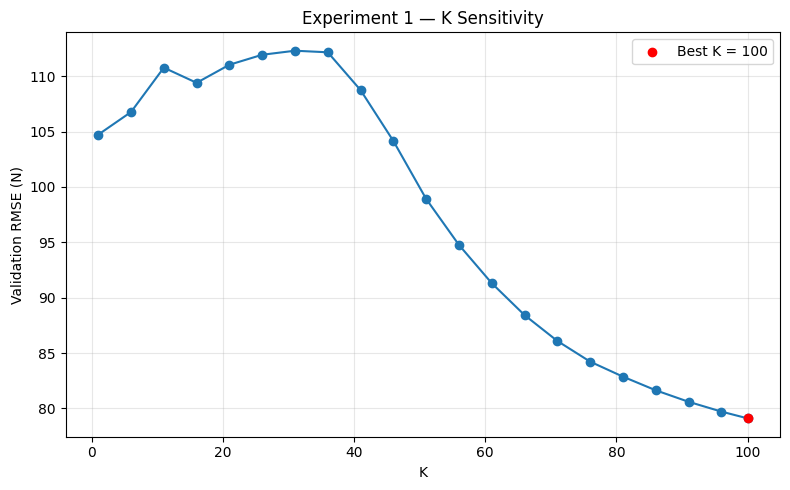

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    score_table["K"],
    score_table["Validation_RMSE_N"],
    marker="o"
)

plt.scatter(
    best_k,
    best_rmse,
    color="red",
    label=f"Best K = {best_k}",
    zorder=3
)

plt.xlabel("K")
plt.ylabel("Validation RMSE (N)")
plt.title("Experiment 1 — K Sensitivity")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "k_sensitivity.png",
    dpi=300
)
plt.show()

score_table.to_csv(
    OUTPUT_PATH / "k_sensitivity.csv",
    index=False
)

### Train the final model

- Use the K selected through validation.
- Fit with training inputs and targets.
- Predict left and right GRF together.

In [20]:
final_model = KNeighborsRegressor(
    n_neighbors=best_k,
    weights=WEIGHTS,
    metric=METRIC,
    n_jobs=-1
)

final_model.fit(
    data["X_train"],
    data["y_train"]
)

print("Selected K:", best_k)
print("Input features:", data["X_train"].shape[1])
print("Output targets:", data["y_train"].shape[1])

Selected K: 100
Input features: 600
Output targets: 600


In [21]:
joblib.dump(
    final_model,
    OUTPUT_PATH / "knn_model_experiment_1.joblib"
)

joblib.dump(
    data["scaler"],
    OUTPUT_PATH / "input_scaler_experiment_one.joblib"
)

print("Model and scaler saved.")

Model and scaler saved.


### Test evaluation

- Predict left and right GRF for test participants.
- Calculate RMSE, Pearson correlation, and R² per side and axis.
- Exclude unmeasured target sides using the Side labels.
- Keep measured zero values in the evaluation.
- Report force errors in Newtons.

In [22]:
test_prediction = final_model.predict(
    data["X_test"]
)

print("Prediction shape:", test_prediction.shape)

Prediction shape: (154, 600)


In [23]:
def evaluate_knn(actual, predicted, sides):
    results = []

    for index, channel in enumerate(GRF_CHANNELS):
        side, axis = channel.split("_")

        mask = np.isin(sides, [side, "Bilateral"])

        start = index * TIME_POINTS
        stop = start + TIME_POINTS

        measured = actual[mask, start:stop].ravel()
        estimated = predicted[mask, start:stop].ravel()

        if measured.size < 2:
            rmse = correlation = r_squared = np.nan
        else:
            rmse = np.sqrt(
                np.mean((estimated - measured) ** 2)
            )

            correlation = (
                pearsonr(measured, estimated)[0]
                if np.std(measured) > 0 and np.std(estimated) > 0
                else np.nan
            )

            r_squared = (
                r2_score(measured, estimated)
                if np.std(measured) > 0
                else np.nan
            )

        results.append({
            "Side": side,
            "Axis": axis,
            "Samples": int(mask.sum()),
            "RMSE_N": rmse,
            "Pearson_r": correlation,
            "R2": r_squared
        })

    return pd.DataFrame(results)

In [24]:
test_results = evaluate_knn(
    data["y_test"],
    test_prediction,
    data["side_test"]
)

display(test_results.round(3))

test_results.to_csv(
    OUTPUT_PATH / "test_metrics.csv",
    index=False
)

print("Test metrics saved.")

,Side,Axis,Samples,RMSE_N,Pearson_r,R2
0,Left,Fx,145,16.426001,0.807,0.558
1,Left,Fy,145,29.674999,0.945,0.866
2,Left,Fz,145,140.102997,0.941,0.841
3,Right,Fx,146,12.443000,0.870,0.681
4,Right,Fy,146,24.891001,0.941,0.843
5,Right,Fz,146,135.261002,0.947,0.865


Test metrics saved.


In [25]:
report = f"""
PELVIS KNN — EXPERIMENT 1
==================================================

INPUTS AND TARGETS
Raw pelvis acceleration and gyroscope
Engineered features: None
Time points: {TIME_POINTS}
Input features: {data["X_train"].shape[1]}
Target features: {data["y_train"].shape[1]}
Target order: {", ".join(GRF_CHANNELS)}
GRF units: Newtons

PARTICIPANT SPLIT
Training: {len(train_ids)}
Validation: {len(val_ids)}
Testing: {len(test_ids)}
Random seed: {SEED}
Participant overlap: {
    bool(
        set(train_ids) & set(val_ids)
        or set(train_ids) & set(test_ids)
        or set(val_ids) & set(test_ids)
    )
}

SAMPLE COUNTS
Training: {len(data["X_train"])}
Validation: {len(data["X_val"])}
Testing: {len(data["X_test"])}

SCALING
StandardScaler fitted on training inputs only
Validation and test inputs use the training scaler
Target scaling: None

MODEL
K-nearest neighbours regression
Distance: {METRIC}
Neighbour weighting: {WEIGHTS}
Final model fitted on training samples only
Left and right GRF predicted together

K SELECTION AND SENSITIVITY
K values tested: {score_table["K"].tolist()}
Selection: Lowest pooled validation RMSE
Selected K: {best_k}
Minimum validation RMSE: {best_rmse:.3f} N
K values within 1% of minimum: {near_best["K"].tolist()}
Selected K at upper boundary: {best_k == score_table["K"].max()}
The 1% tolerance is descriptive, not proof of stability.

VALIDATION RESULTS
{score_table.round(3).to_string(index=False)}

EVALUATION
Metrics pooled across samples and time points per side and axis
Unmeasured sides excluded using Side labels
Measured zero values retained
Test data excluded from K selection

TEST RESULTS
{test_results.round(3).to_string(index=False)}

LIMITATION
Zero-filled unmeasured targets remain in training.
Their effect on predictions has not been quantified.
Exclusion during scoring depends on accurate Side labels.
"""

report_file = OUTPUT_PATH / "experiment_one_experiment_summary.txt"
report_file.write_text(report, encoding="utf-8")

print(report)
print("Saved:", report_file)


PELVIS KNN — EXPERIMENT 1

INPUTS AND TARGETS
Raw pelvis acceleration and gyroscope
Engineered features: None
Time points: 100
Input features: 600
Target features: 600
Target order: Left_Fx, Left_Fy, Left_Fz, Right_Fx, Right_Fy, Right_Fz
GRF units: Newtons

PARTICIPANT SPLIT
Training: 40
Validation: 9
Testing: 9
Random seed: 42
Participant overlap: False

SAMPLE COUNTS
Training: 696
Validation: 165
Testing: 154

SCALING
StandardScaler fitted on training inputs only
Validation and test inputs use the training scaler
Target scaling: None

MODEL
K-nearest neighbours regression
Distance: euclidean
Neighbour weighting: uniform
Final model fitted on training samples only
Left and right GRF predicted together

K SELECTION AND SENSITIVITY
K values tested: [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96, 100]
Selection: Lowest pooled validation RMSE
Selected K: 100
Minimum validation RMSE: 79.100 N
K values within 1% of minimum: [96, 100]
Selected K at upper bound